In [6]:
import pandas as pd

df = pd.read_csv('apollo_data.csv').drop(columns=['Unnamed: 0'])
print(df)

      age     sex smoker     region  viral load  severity level  \
0      19  female    yes  southwest        9.30               0   
1      18    male     no  southeast       11.26               1   
2      28    male     no  southeast       11.00               3   
3      33    male     no  northwest        7.57               0   
4      32    male     no  northwest        9.63               0   
...   ...     ...    ...        ...         ...             ...   
1333   50    male     no  northwest       10.32               3   
1334   18  female     no  northeast       10.64               0   
1335   18  female     no  southeast       12.28               0   
1336   21  female     no  southwest        8.60               0   
1337   61  female    yes  northwest        9.69               0   

      hospitalization charges  
0                       42212  
1                        4314  
2                       11124  
3                       54961  
4                        9667  
...

In [7]:
import pandas as pd
import numpy as np

model_df = df.copy()

# Rename columns to make formula/model handling easier
model_df = model_df.rename(
    columns={
        "viral load": "viral_load",
        "severity level": "severity_level",
        "hospitalization charges": "hospitalization_charges"
    }
)

# Convert binary categorical variables to numeric
model_df["sex_male"] = model_df["sex"].map({
    "female": 0,
    "male": 1
})

model_df["smoker_yes"] = model_df["smoker"].map({
    "no": 0,
    "yes": 1
})

# Ensure the target is numeric and ordered
model_df["severity_level"] = pd.to_numeric(
    model_df["severity_level"],
    errors="coerce"
)

model_df = model_df.dropna(
    subset=[
        "region",
        "severity_level",
        "age",
        "viral_load",
        "sex_male",
        "smoker_yes"
    ]
)

In [8]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

predictors = [
    "age",
    "sex_male",
    "smoker_yes",
    "viral_load"
]

regional_results = {}

for region in sorted(model_df["region"].unique()):

    region_df = model_df.loc[
        model_df["region"].eq(region)
    ].copy()

    X = region_df[predictors]
    y = region_df["severity_level"].astype(int)

    # logit = ordinal logistic regression
    model = OrderedModel(
        y,
        X,
        distr="logit"
    )

    result = model.fit(
        method="bfgs",
        disp=False
    )

    regional_results[region] = result

    print(f"\n{'=' * 70}")
    print(f"Region: {region}")
    print(f"{'=' * 70}")
    print(result.summary())


Region: northeast
                             OrderedModel Results                             
Dep. Variable:         severity_level   Log-Likelihood:                -444.30
Model:                   OrderedModel   AIC:                             906.6
Method:            Maximum Likelihood   BIC:                             940.6
Date:                Mon, 20 Jul 2026                                         
Time:                        00:27:05                                         
No. Observations:                 324                                         
Df Residuals:                     315                                         
Df Model:                           4                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
age            0.0028      0.008      0.370      0.711      -0.012       0.018
sex_male       0.0236      0.205 

In [9]:
significance_tables = []

for region, result in regional_results.items():

    region_results = pd.DataFrame({
        "variable": result.params.index,
        "coefficient": result.params.values,
        "p_value": result.pvalues.values
    })

    # Retain only actual predictors
    region_results = region_results[
        region_results["variable"].isin(predictors)
    ].copy()

    region_results["region"] = region
    region_results["odds_ratio"] = np.exp(
        region_results["coefficient"]
    )

    region_results["significant_5pct"] = (
        region_results["p_value"] < 0.05
    )

    significance_tables.append(region_results)

significance_results = pd.concat(
    significance_tables,
    ignore_index=True
)

significance_results = significance_results[
    [
        "region",
        "variable",
        "coefficient",
        "odds_ratio",
        "p_value",
        "significant_5pct"
    ]
].sort_values(
    ["region", "p_value"]
)

significance_results

,region,variable,coefficient,odds_ratio,p_value,significant_5pct
2,northeast,smoker_yes,0.122558,1.130385,0.617996,False
3,northeast,viral_load,-0.024300,0.975993,0.645474,False
0,northeast,age,0.002847,1.002851,0.711324,False
1,northeast,sex_male,0.023620,1.023901,0.908093,False
7,northwest,viral_load,0.084283,1.087937,0.155348,False
4,northwest,age,0.006932,1.006957,0.351114,False
5,northwest,sex_male,0.165336,1.179790,0.413957,False
6,northwest,smoker_yes,0.211090,1.235024,0.433652,False
8,southeast,age,0.014434,1.014539,0.038958,True
11,southeast,viral_load,-0.027962,0.972425,0.532390,False


In [10]:
significant_predictors = significance_results.loc[
    significance_results["significant_5pct"]
].copy()

significant_predictors

,region,variable,coefficient,odds_ratio,p_value,significant_5pct
8,southeast,age,0.014434,1.014539,0.038958,True


In [11]:
regional_summary = (
    significance_results
    .groupby("region")
    .apply(
        lambda x: ", ".join(
            x.loc[x["significant_5pct"], "variable"]
        ) or "No significant predictors"
    )
    .reset_index(name="significant_predictors")
)

regional_summary

/tmp/ipykernel_905/1674386338.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,region,significant_predictors
0,northeast,No significant predictors
1,northwest,No significant predictors
2,southeast,age
3,southwest,No significant predictors


In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

model_df = df.copy()

model_df = model_df.rename(
    columns={
        "viral load": "viral_load",
        "severity level": "severity_level",
        "hospitalization charges": "hospitalization_charges"
    }
)

model_df["smoker_yes"] = model_df["smoker"].map({
    "no": 0,
    "yes": 1
})

model_df = model_df.dropna(
    subset=[
        "viral_load",
        "smoker_yes",
        "severity_level",
        "hospitalization_charges"
    ]
)

In [13]:
X = model_df[
    [
        "viral_load",
        "smoker_yes",
        "severity_level"
    ]
]

y = model_df["hospitalization_charges"]

# Add intercept
X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                               OLS Regression Results                              
Dep. Variable:     hospitalization_charges   R-squared:                       0.662
Model:                                 OLS   Adj. R-squared:                  0.661
Method:                      Least Squares   F-statistic:                     869.0
Date:                     Mon, 20 Jul 2026   Prob (F-statistic):          3.89e-313
Time:                             00:29:36   Log-Likelihood:                -14979.
No. Observations:                     1338   AIC:                         2.997e+04
Df Residuals:                         1334   BIC:                         2.999e+04
Df Model:                                3                                         
Covariance Type:                 nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [14]:
results_table = pd.DataFrame({
    "coefficient": ols_model.params,
    "std_error": ols_model.bse,
    "t_statistic": ols_model.tvalues,
    "p_value": ols_model.pvalues,
    "ci_lower": ols_model.conf_int()[0],
    "ci_upper": ols_model.conf_int()[1]
})

results_table["significant_5pct"] = (
    results_table["p_value"] < 0.05
)

results_table

,coefficient,std_error,t_statistic,p_value,ci_lower,ci_upper,significant_5pct
const,-10169.404330,2516.429563,-4.041204,5.621453e-05,-15105.994640,-5232.814020,True
viral_load,2899.596759,237.262618,12.221043,1.240536e-32,2434.148268,3365.045250,True
smoker_yes,58951.075447,1194.670973,49.345030,3.760951e-303,56607.436970,61294.713923,True
severity_level,1494.006855,400.099673,3.734087,1.963345e-04,709.113768,2278.899943,True


In [15]:
model_performance = pd.DataFrame({
    "metric": [
        "R-squared",
        "Adjusted R-squared",
        "F-statistic",
        "F-test p-value",
        "RMSE",
        "MAE"
    ],
    "value": [
        ols_model.rsquared,
        ols_model.rsquared_adj,
        ols_model.fvalue,
        ols_model.f_pvalue,
        np.sqrt(np.mean(ols_model.resid ** 2)),
        np.mean(np.abs(ols_model.resid))
    ]
})

model_performance

,metric,value
0,R-squared,6.615016e-01
1,Adjusted R-squared,6.607403e-01
2,F-statistic,8.689781e+02
3,F-test p-value,3.885784e-313
4,RMSE,1.760762e+04
5,MAE,1.345516e+04


In [16]:
model_df["hospitalization_charges"].describe()

,hospitalization_charges
count,1338.000000
mean,33176.058296
std,30275.029296
min,2805.000000
25%,11851.000000
50%,23455.000000
75%,41599.500000
max,159426.000000


<Axes: >

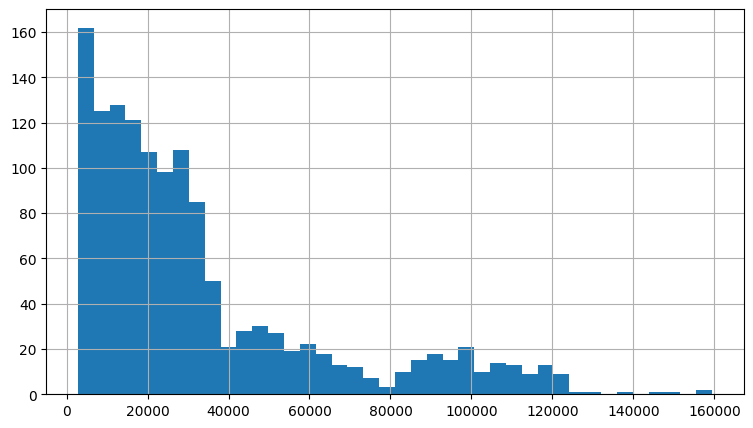

In [17]:
model_df["hospitalization_charges"].hist(
    bins=40,
    figsize=(9, 5)
)

In [18]:
model_df["log_charges"] = np.log1p(
    model_df["hospitalization_charges"]
)

X = model_df[
    [
        "viral_load",
        "smoker_yes",
        "severity_level"
    ]
]

X = sm.add_constant(X)

log_ols_model = sm.OLS(
    model_df["log_charges"],
    X
).fit()

print(log_ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     416.7
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          5.96e-191
Time:                        00:30:43   Log-Likelihood:                -1343.4
No. Observations:                1338   AIC:                             2695.
Df Residuals:                    1334   BIC:                             2716.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              8.9834      0.094     95.

In [19]:
log_effects = pd.DataFrame({
    "coefficient": log_ols_model.params,
    "percentage_change": (
        np.exp(log_ols_model.params) - 1
    ) * 100,
    "p_value": log_ols_model.pvalues
})

log_effects

,coefficient,percentage_change,p_value
const,8.983357,796834.134125,0.000000e+00
viral_load,0.058008,5.972336,1.003216e-10
smoker_yes,1.512015,353.586276,5.451677e-181
severity_level,0.117920,12.515422,7.971665e-15


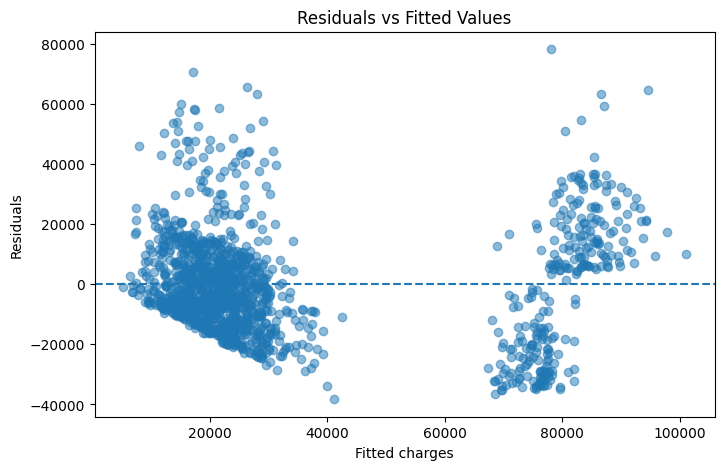

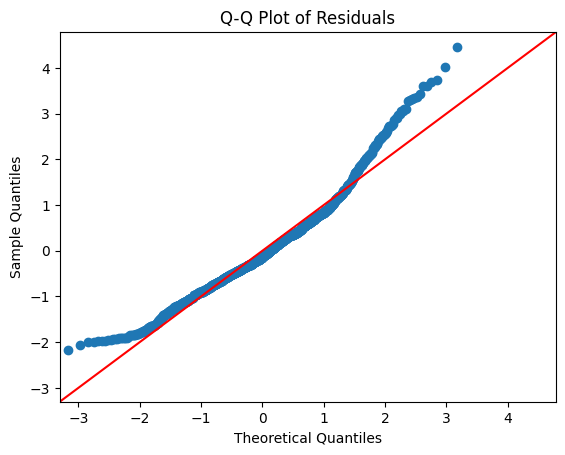

In [20]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Residuals versus fitted values
plt.figure(figsize=(8, 5))
plt.scatter(
    ols_model.fittedvalues,
    ols_model.resid,
    alpha=0.5
)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# Q-Q plot
sm.qqplot(
    ols_model.resid,
    line="45",
    fit=True
)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [21]:
robust_ols_model = ols_model.get_robustcov_results(
    cov_type="HC3"
)

print(robust_ols_model.summary())

                               OLS Regression Results                              
Dep. Variable:     hospitalization_charges   R-squared:                       0.662
Model:                                 OLS   Adj. R-squared:                  0.661
Method:                      Least Squares   F-statistic:                     553.2
Date:                     Mon, 20 Jul 2026   Prob (F-statistic):          1.55e-233
Time:                             00:31:16   Log-Likelihood:                -14979.
No. Observations:                     1338   AIC:                         2.997e+04
Df Residuals:                         1334   BIC:                         2.999e+04
Df Model:                                3                                         
Covariance Type:                       HC3                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------